# Problem 5
***

### a)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import accumulate 
from itertools import islice


In [15]:
# Define the ticker. For each of the tickers I add the corresponding names. 

tickers = {
    'AAPL': 'Apple',
    'AAL': 'American airlines',
    'TSLA': 'Tesla',
    'GC=F': 'Gold',
    'CL=F': 'Crude oil',
    # Also adding equinor last again. Only using american stocks to be compatible.
    'EQNR': 'Equinor'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-01-01'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
# Adjusted close column with the correct index.
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date, ignore_tz=True, progress=False )['Adj Close']

In [16]:
# Assuming that all of the assets are equally weighted, and the most severe downfall will be the biggest difference in the asset. 
# To achieve equal weight, I divide all values on the first value in each column and averaging them. 

# Tickers but without equinor
exept_eq = list(tickers.items())[:-1]
weighted = {}

for ticker, name in exept_eq:
    weighted[name] = data[name]/data[name].iloc[0] 

weighted = pd.DataFrame(weighted)
weighted.dropna(inplace=True)

asset = weighted.mean(axis=1)

In [4]:
# Using lecture notes to find the most severe downfalls. 
i = np.argmax(np.maximum.accumulate(asset)-asset) # end of the period
j = np.argmax(asset[:i]) # start of period

i2 = np.argmax(np.maximum.accumulate(asset[:j]) - asset[:j]) # end of the period limited to j
j2 = np.argmax(asset[:i2]) # start of period

i3 = np.argmax(np.maximum.accumulate(asset[:j2]) - asset[:j2]) # end of the period limited by j2
j3 = np.argmax(asset[:i3]) # start of period



2021-11-04 00:00:00 2022-12-27 00:00:00
2021-01-26 00:00:00 2021-03-08 00:00:00
2020-08-31 00:00:00 2020-09-08 00:00:00


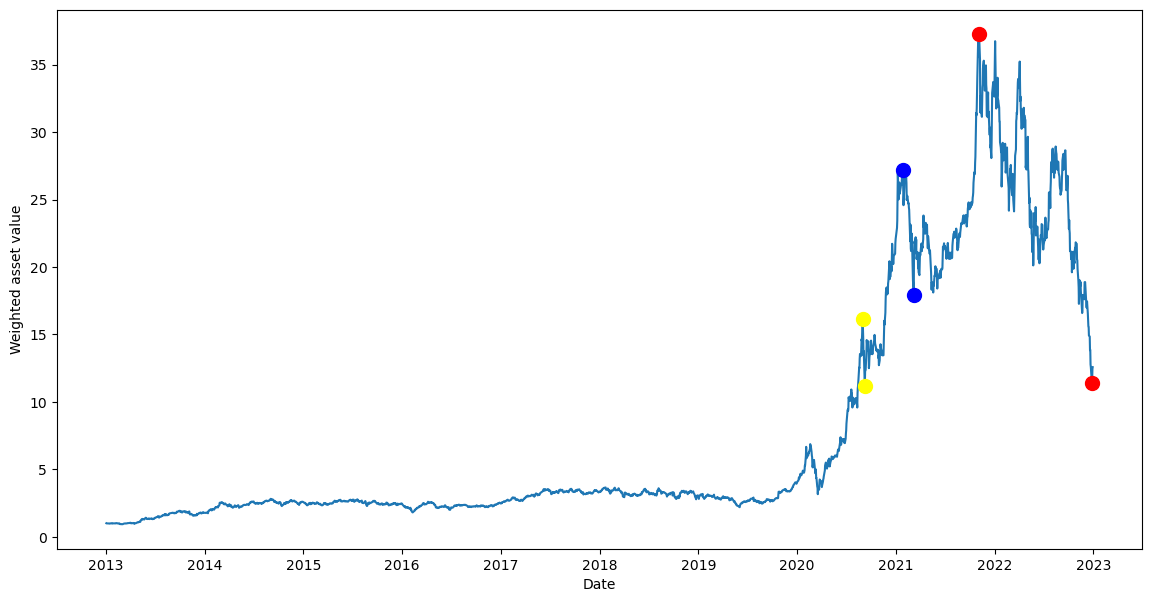

In [5]:
# Plotting the dots, where the biggest downfall is red, second biggest is blue and the least is yellow. 
plt.figure(figsize=(14,7))
plt.xlabel('Date')
plt.ylabel('Weighted asset value')
plt.plot(asset)
plt.plot([asset.index[i], asset.index[j]], [asset[i], asset[j]], 'o', color='Red', markersize=10)
plt.plot([asset.index[i2], asset.index[j2]], [asset[i2], asset[j2]], 'o', color='Blue', markersize=10)
plt.plot([asset.index[i3], asset.index[j3]], [asset[i3], asset[j3]], 'o', color='Yellow', markersize=10)




print(asset.index[j],asset.index[i])
print(asset.index[j2],asset.index[i2])
print(asset.index[j3],asset.index[i3])

Equinor change in downfall period 1:  11.601678848266602
Equinor change in downfall period 2:  -0.08000946044921875
Equinor change in downfall period 3:  -0.2866544723510742


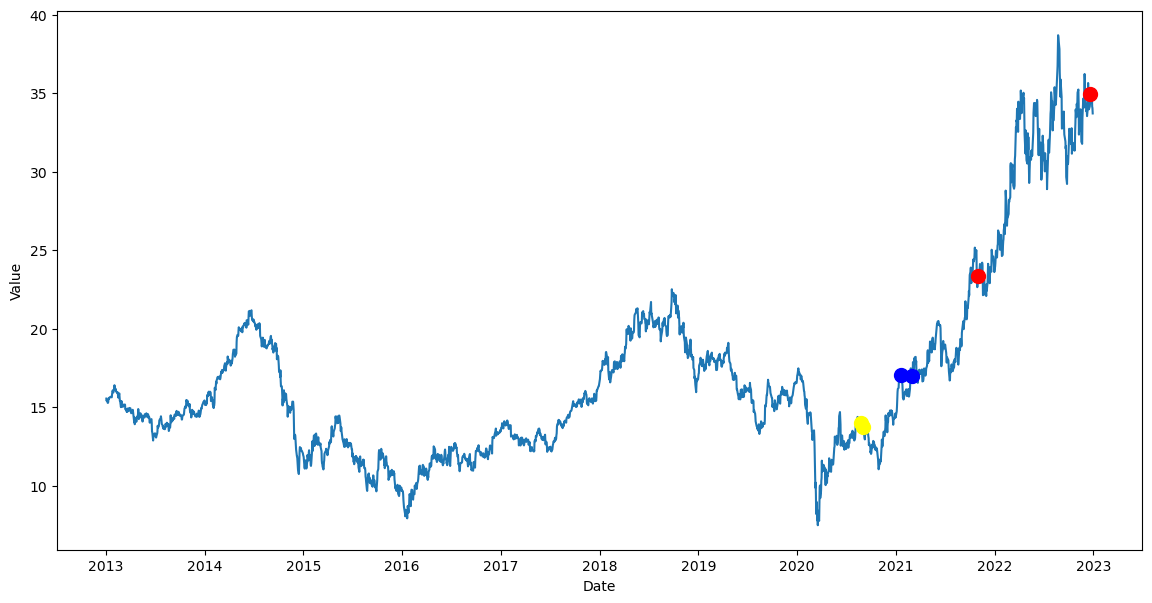

In [6]:
# Plotting the same dots on the Equinor stock to review the downfall periods on this stock.
plt.figure(figsize=(14,7))
plt.xlabel('Date')
plt.ylabel('Value')
plt.plot(data["Equinor"])

plt.plot([data["Equinor"].index[i], data["Equinor"].index[j]], [data["Equinor"][i], data["Equinor"][j]], 'o', color='Red', markersize=10)
plt.plot([data["Equinor"].index[i2], data["Equinor"].index[j2]], [data["Equinor"][i2], data["Equinor"][j2]], 'o', color='Blue', markersize=10)
plt.plot([data["Equinor"].index[i3], data["Equinor"].index[j3]], [data["Equinor"][i3], data["Equinor"][j3]], 'o', color='Yellow', markersize=10)

print("Equinor change in downfall period 1: ", data["Equinor"].iloc[i]-data["Equinor"].iloc[j])
print("Equinor change in downfall period 2: ", data["Equinor"].iloc[i2]-data["Equinor"].iloc[j2])
print("Equinor change in downfall period 3: ", data["Equinor"].iloc[i3]-data["Equinor"].iloc[j3])

##### We then see that the biggest downfall periods are between 4. November 2021 and 27. december 2022, 26. January and 8. March 2021 and 31. August and 8. September 2020. For Equinor, we see that there is a increase instead in the largest downfall period. The other two are just around 0. This means that there is no downfall period for Equinor in these periods. 

***
### b)

In [7]:
# Saying that the growth periods I look at are between the downfall periods. 

print("Equinor change in growth period 1: ", data["Equinor"].iloc[j3]-data["Equinor"].iloc[0])
print("Equinor change in growth period 2: ", data["Equinor"].iloc[j2]-data["Equinor"].iloc[i3])
print("Equinor change in growth period 3: ", data["Equinor"].iloc[j]-data["Equinor"].iloc[i2])


Equinor change in growth period 1:  -1.5266036987304688
Equinor change in growth period 2:  3.3273448944091797
Equinor change in growth period 3:  6.3870086669921875


##### When looking at the growth periods, we also see an increase in the Equinor stock. This is not as much as the increase we saw when the stocks had a downfall period. As well as this, we can see that the last downfall period is the one with the biggest increase in Equinor stock. This could make us believe that the stock now is negatively correlated with the five assets in downfall periods in the close future. 

***
### c) 

##### Based on the information found in a) and b), I could suggest a trading strategy. When we see an underperformance of the stocks in the portfolio I created, we buy the Equinor stock, while it is not we sell. To find out if it has an underperformance we can use SMA. If the long term moving average is above the short term moving average, we could assume that they are underperforming and we buy the Equinor asset. When it is the opposite we sell. 

***
### d)

In [47]:
# Creating SMA short and long. Using the lecture notes for inspiration.

# Using 30 days for short and 200 for long. No particular reason, other than the periods are not that large, and therefore I think the SMA short
# should be smaller. 

SMA1 = 30
SMA2 = 200

# Creating the rolling average for short and long.
asset = (pd.DataFrame(asset))

asset["sma1"] = asset[0].rolling(SMA1).mean()
asset["sma2"] = asset[0].rolling(SMA2).mean()
asset["signal"] = np.where(asset["sma2"] > asset["sma1"], 1 , 0)

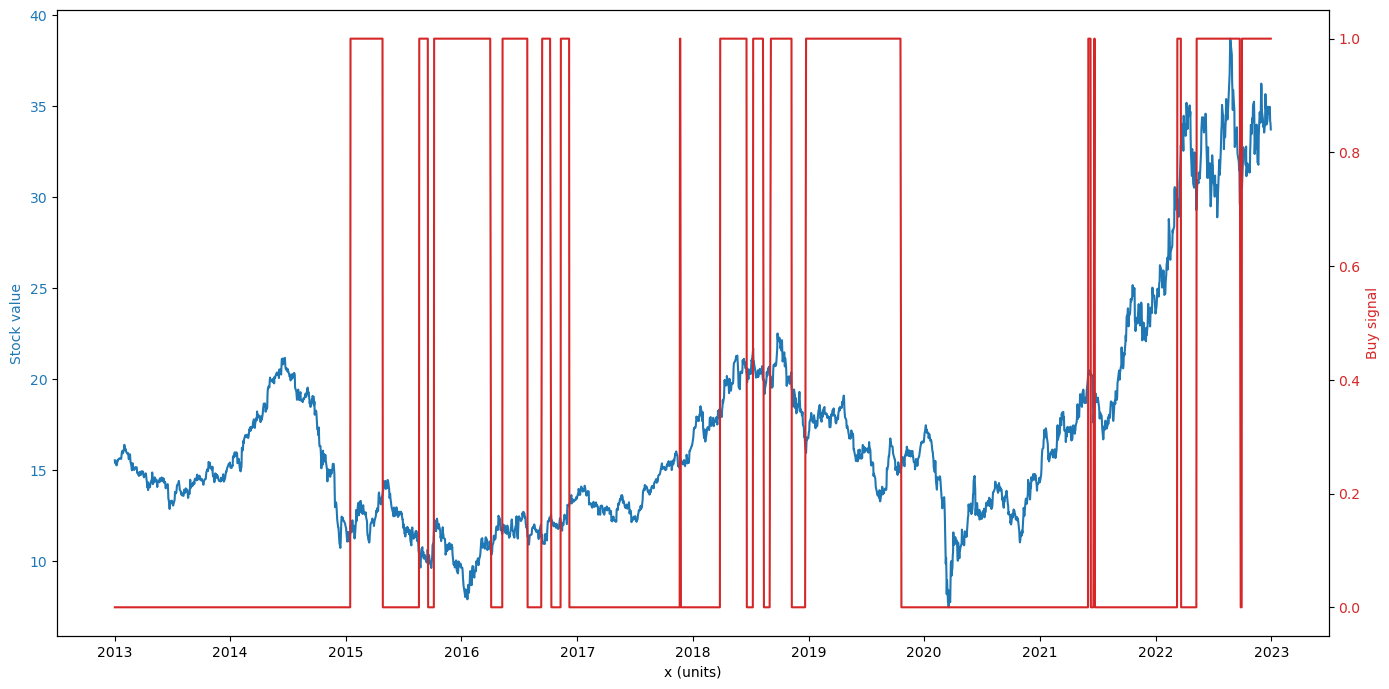

In [48]:
# Create some example data
fig, ax1 = plt.subplots(figsize = (14,7))


ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Buy signal', color=color)  # we already handled the x-label with ax1
ax2.plot(asset["signal"], color=color)
ax2.tick_params(axis='y', labelcolor=color)

color = 'tab:blue'
ax1.set_xlabel('x (units)')
ax1.set_ylabel('Stock value', color=color)
ax1.plot(data["Equinor"], color=color,label = "Adjusted close Equinor")
ax1.tick_params(axis='y', labelcolor=color)



fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


##### Looking at this graph we see that when the red signals are on 1, we buy the stock. And when it is on 0, we don't hold it. 

<AxesSubplot:xlabel='Date'>

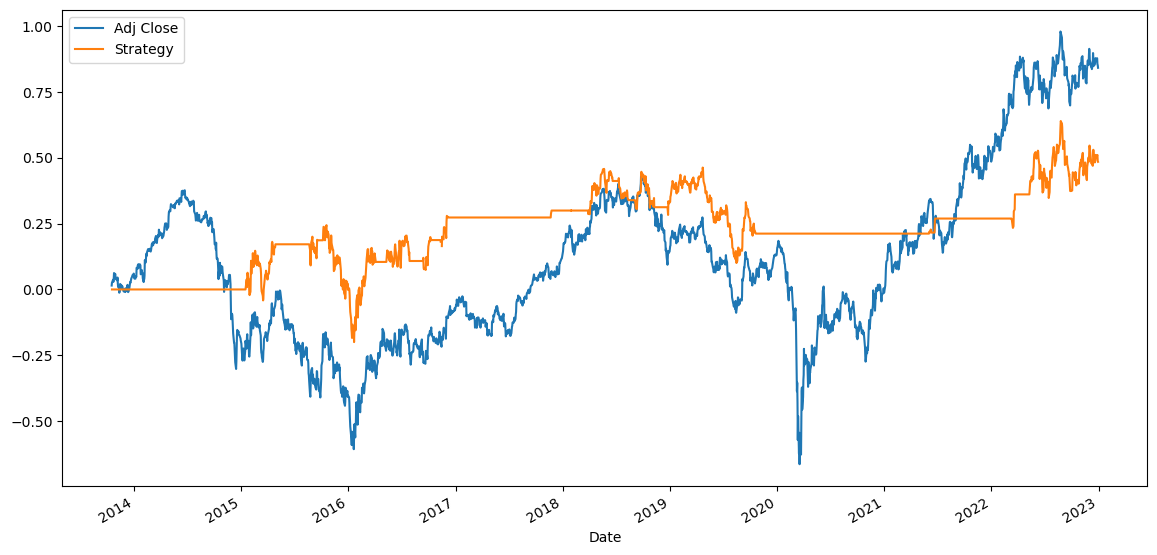

In [49]:
# Adding together only when the strategy says to buy. Shifting with one to make the signal work for the next day, and not the same day.

log_return = np.log(data["Equinor"] / data["Equinor"].shift(1))


Portfolio2 = (pd.DataFrame(log_return[SMA2:].cumsum()).dropna())
Portfolio2['Strategy'] = (log_return[SMA2:]*asset['signal'][SMA2:]).shift(1).cumsum()
Portfolio2.plot(figsize = (14,7))

##### Looking at the figure created with the strategy, we see that the strategy is not better than holding the stock. We see that the large growth period from 2020 to 2023 is not included, which misses out on a lot of value. 